In [2]:
! mkdir ~/.kaggle

In [3]:
! mv kaggle.json ~/.kaggle

In [4]:
!ls -a  ~/.kaggle

.  ..  kaggle.json


In [5]:
!kaggle datasets download -d aima138/17flowerclasses

Dataset URL: https://www.kaggle.com/datasets/aima138/17flowerclasses
License(s): unknown
100% 57.8M/57.8M [00:05<00:00, 11.9MB/s]



In [12]:
#!unzip 17flowerclasses.zip

Found 1190 images belonging to 17 classes.
Found 170 images belonging to 17 classes.
Number of classes: 17
Class names: {'Bluebell': 0, 'ButterCup': 1, 'ColtsFoot': 2, 'Cowslip': 3, 'Crocus': 4, 'Daffodil': 5, 'Daisy': 6, 'Dandelion': 7, 'Fritillary': 8, 'Iris': 9, 'LilyValley': 10, 'Pansy': 11, 'Snowdrop': 12, 'Sunflower': 13, 'Tigerlily': 14, 'WindFlower': 15, 'tulip': 16}


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 17)             │         8,721 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,116,241 (19.52 MB)

 Trainable params: 5,116,241 (19.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 16s 309ms/step - accuracy: 0.0975 - loss: 2.6965 - val_accuracy: 0.1176 - val_loss: 2.3943
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 214ms/step - accuracy: 0.1672 - loss: 2.3426 - val_accuracy: 0.2000 - val_loss: 2.3292
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 194ms/step - accuracy: 0.2336 - loss: 2.1362 - val_accuracy: 0.2529 - val_loss: 2.0908
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 215ms/step - accuracy: 0.3008 - loss: 1.9680 - val_accuracy: 0.3059 - val_loss: 1.9104
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 216ms/step - accuracy: 0.3815 - loss: 1.7412 - val_accuracy: 0.3882 - val_loss: 1.7452
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 188ms/step - accuracy: 0.4437 - loss: 1.5657 - val_accuracy: 0.3882 - val_loss: 1.7037
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 206ms/step - accuracy: 0.4689 - loss: 1.4994 - val_accuracy: 0.3529 - val_loss: 1.9224
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 204ms/step - accuracy: 0.4866 - loss: 1.4724 - val_accuracy: 0

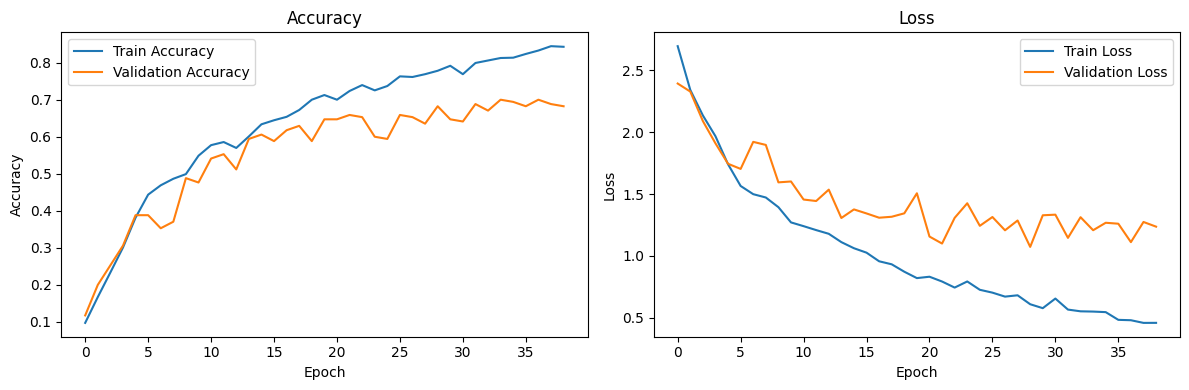

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import os

#paths.
data_dir = "/content/17flowerclasses"
train_dir = os.path.join(data_dir, "train")
test_dir = os.path.join(data_dir, "test")

#define training parameters.
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
NUM_CLASSES = 17
EPOCHS = 50

#create training augmentation.
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

#test preprocessing.
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

#training data.
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

#test data.
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

#print dataset information.
print(f"Number of classes: {train_generator.num_classes}")
print(f"Class names: {train_generator.class_indices}")

#build CNN model.
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),

    layers.Dropout(0.5),

    layers.Dense(512, activation="relu"),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

#show model summary.
model.summary()

#compile the model.
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

#early stopping callback.
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

#model checkpoint callback.
checkpoint = ModelCheckpoint(
    "best_flower_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

#train the model.
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

#evaluate the model.
test_loss, test_acc = model.evaluate(
    test_generator,
    verbose=0
)

print(f"\nTest Accuracy: {test_acc:.4f}")

#plot training accuracy and loss.
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

#load the best saved model.
best_model = tf.keras.models.load_model(
    "best_flower_model.keras"
)

#create index to class mapping.
idx_to_class = {
    v: k for k, v in train_generator.class_indices.items()
}



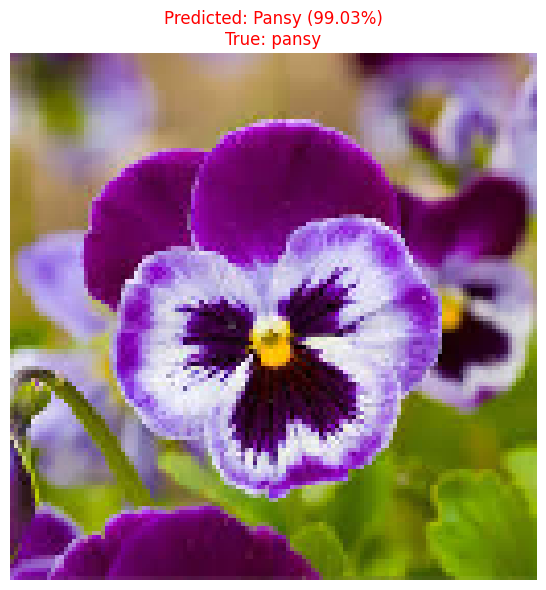

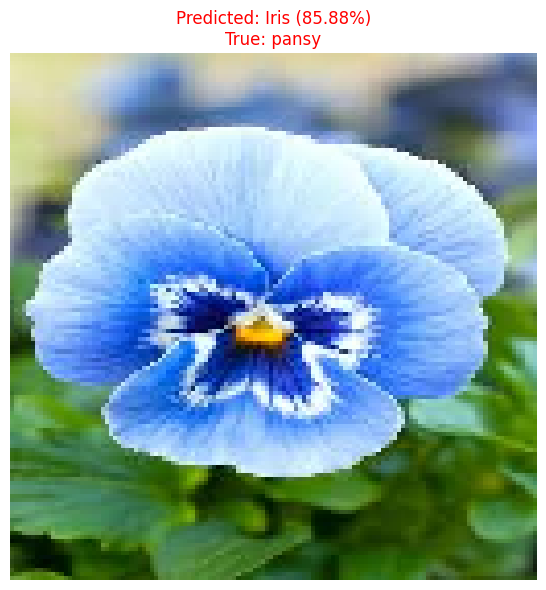

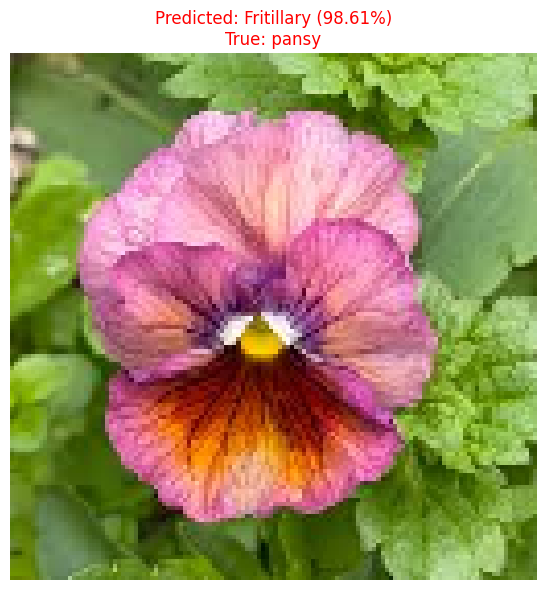

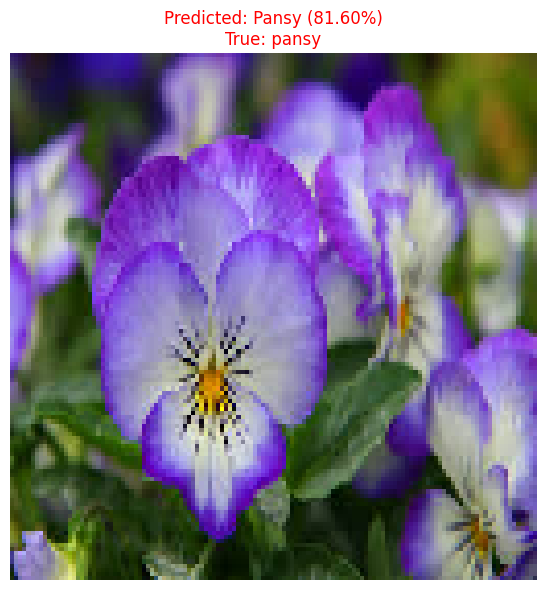

'Pansy'

In [14]:
#predict and display an image.
def predict_and_display(img_path, true_label=None):

    #load and resize the image.
    img = image.load_img(
        img_path,
        target_size=IMG_SIZE
    )

    #convert image to array.
    img_array = image.img_to_array(img)

    #normalize pixel values.
    img_array = img_array / 255.0

    #add batch dimension.
    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    #predict the image class.
    predictions = best_model.predict(
        img_array,
        verbose=0
    )

    #get prediction information.
    predicted_idx = np.argmax(
        predictions[0]
    )

    confidence = np.max(
        predictions[0]
    ) * 100

    predicted_class = idx_to_class[
        predicted_idx
    ]

    #display the image.
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")

    #display title.
    if true_label is not None:

        color = (
            "green"
            if predicted_class == true_label
            else "red"
        )

        title = (
            f"Predicted: {predicted_class} "
            f"({confidence:.2f}%)\n"
            f"True: {true_label}"
        )

    else:

        color = "blue"

        title = (
            f"Predicted: {predicted_class} "
            f"({confidence:.2f}%)"
        )

    plt.title(
        title,
        color=color,
        fontsize=12
    )

    plt.tight_layout()
    plt.show()

    return predicted_class

#test predictions.
predict_and_display("/content/pansy1.jpg", "pansy")
predict_and_display("/content/pansy4.jpg", "pansy")
predict_and_display("/content/pansy5.jpg", "pansy")
predict_and_display("/content/pansy6.jpg", "pansy")